<a href="https://colab.research.google.com/github/lomnitzs-maker/sophia/blob/main/CodingHomework8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Sophia Lomnitz
*Neur 265*

**4/8/26**

In [66]:
# importing necessary modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [65]:
# importing data
shock_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv', delimiter = ',').astype(int)
tone_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv', delimiter = ',').astype(int)
fear_traces = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv',delimiter=',')
extinction_predictors = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv',delimiter=',')

In [69]:
# making variables for condtioning taces and extinction traces
conditioning_traces = fear_traces[0:10458,:]
extinction_traces = fear_traces[10458:,:]

In [70]:
# printing sizes of both arrays
print(conditioning_traces.shape)
print(extinction_traces.shape)

(10458, 63)
(14210, 63)


In [71]:
# making time variables
time_condtioning = np.linspace(0,10458/15,10458)
time_extinction = np.linspace(0,14210/15,14210)

The number of ROIs is 63. The condtioning lasted 697.2 seconds (11.62 minutes), and the exctiction lasted 947.33 seconds  (15.79 minutes).

Text(0.5, 1.0, 'Extinction Traces')

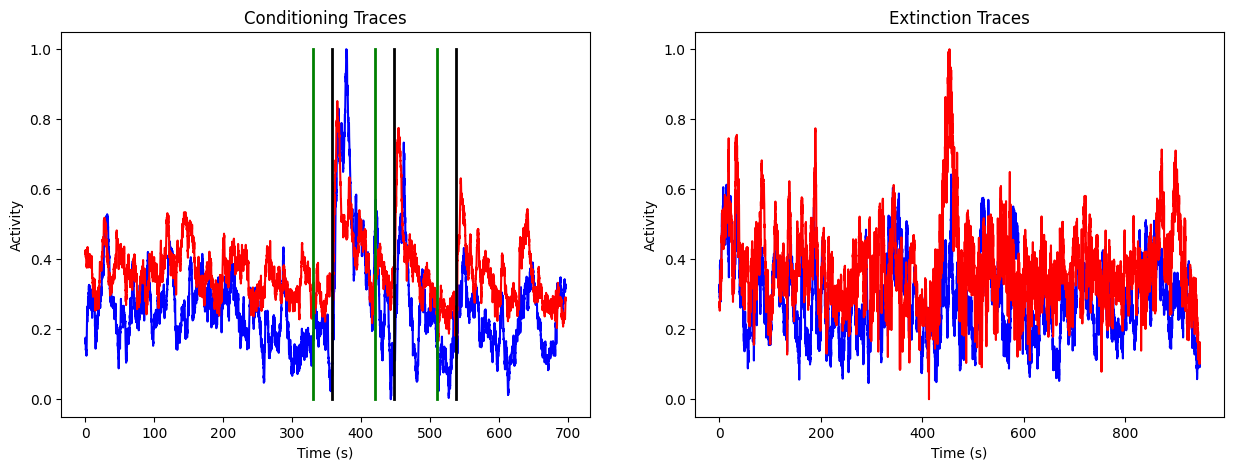

In [73]:
# plotting the first and second ROIs in one subplot for each variable
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(time_condtioning, conditioning_traces[:,0], color="blue", label="ROI 1")
ax[0].plot(time_condtioning, conditioning_traces[:,1], color="red",label="ROI 2")
for t in tone_index:
    ax[0].plot([t, t], [0, 1], lw=2, color="green")

for s in shock_index:
    ax[0].plot([s, s], [0, 1], lw=2, color="black")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Activity")
ax[0].set_title("Conditioning Traces")

ax[1].plot(time_extinction, extinction_traces[:,0], color="blue",label="ROI 1")
ax[1].plot(time_extinction, extinction_traces[:,1],color="red", label="ROI 2")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Activity")
ax[1].set_title("Extinction Traces")

There seems to be a lot more activity during the exctinction, a lot more peaks and troughs.

In [74]:
# importing more necessary materials
from pandas import DataFrame as df
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from statsmodels.genmod.families.links import identity, log
from scipy.stats import chi2
from statsmodels.distributions.empirical_distribution import ECDF


In [75]:
#using code from class noteboook to make a variable that condatins shock onset and tone onset
shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

  tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

predictors_conditioning = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array})
model1 = sm.GLM(shock_array, predictors_conditioning, family=Poisson())
model1_results = model1.fit()

predictors_conditioning['shock onset'] = shock_array
model3 = sm.GLM(tone_array, predictors_conditioning, family=Poisson())
model3_results = model3.fit() # Fit model to our data
b1 = model3_results.params

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


Text(0, 0.5, 'Cumulative Proportion of ROIs')

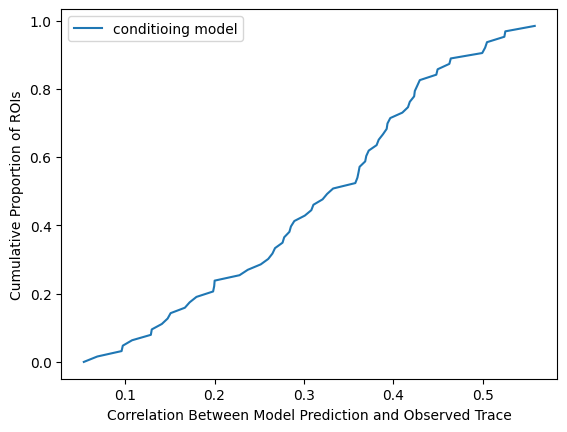

In [82]:
# running model for each ROI in conditioing_traces array
predictors_conditioning['shock onset'] = shock_array
num_rois = conditioning_traces.shape[1]
r_index_conditioning = np.zeros(num_rois)

for i in range(num_rois):
  trace_temp = conditioning_traces[:,i]
  model3 = sm.GLM(trace_temp, predictors_conditioning, family=Poisson())
  model3_results = model3.fit()
  predicted_trace = model3_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_index_conditioning[i] = r3.statistic

plt.plot(np.sort(r_index_conditioning), np.linspace(0, 1, len(r_index_conditioning), endpoint=False), label = "conditioing model")
#plt.plot(np.sort(r_model2), np.linspace(0, 1, len(r_model2), endpoint=False), label = "model 2")
#plt.plot(np.sort(r_model3), np.linspace(0, 1, len(r_model3), endpoint=False), label = "model 3")
plt.legend()
plt.xlabel('Correlation Between Model Prediction and Observed Trace')
plt.ylabel('Cumulative Proportion of ROIs')

Text(0, 0.5, 'Cumulative Proportion of ROIs')

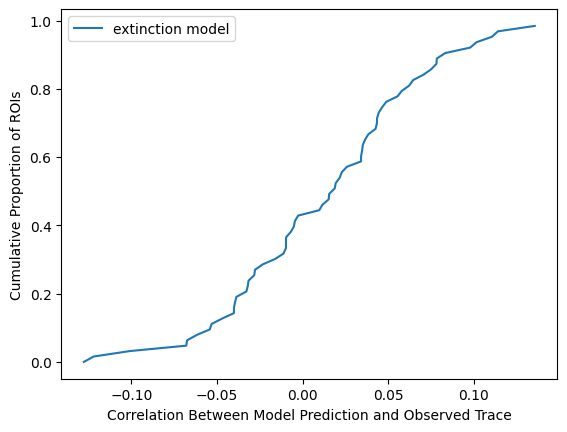

In [87]:
# doing the same for extinction traces array
num_rois = extinction_traces.shape[1]
r_index_extinction = np.zeros(num_rois)

extinction_predictors = extinction_predictors[:14210]
extinction_predictors = extinction_predictors.reshape(-1, 1)

for i in range(num_rois):
    trace_temp = extinction_traces[:, i]
    model_ext = sm.GLM(trace_temp, extinction_predictors, family=Poisson())
    model_ext_results = model_ext.fit()
    predicted_trace = model_ext_results.predict()
    r_ext = pearsonr(trace_temp, predicted_trace)
    r_index_extinction[i] = r_ext.statistic
plt.plot(np.sort(r_index_extinction), np.linspace(0, 1, len(r_index_extinction), endpoint=False), label = "extinction model")
#plt.plot(np.sort(r_model2), np.linspace(0, 1, len(r_model2), endpoint=False), label = "model 2")
#plt.plot(np.sort(r_model3), np.linspace(0, 1, len(r_model3), endpoint=False), label = "model 3")
plt.legend()
plt.xlabel('Correlation Between Model Prediction and Observed Trace')
plt.ylabel('Cumulative Proportion of ROIs')

In [84]:
# using pearsonr to correlate two variables
r_compare = pearsonr(r_index_conditioning, r_index_extinction)
print(r_compare)

PearsonRResult(statistic=np.float64(0.014779730798122465), pvalue=np.float64(0.9084708216602402))


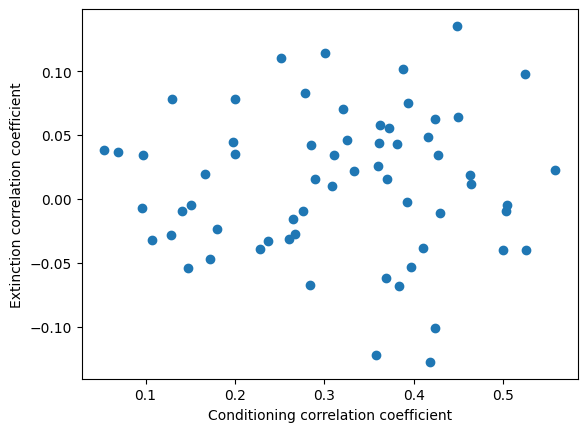

In [85]:
# making a scatter plot with r_index_conditioing on the x-axis and r_index_extinction on the y-axis
plt.figure()
plt.scatter(r_index_conditioning, r_index_extinction)
plt.xlabel("Conditioning correlation coefficient")
plt.ylabel("Extinction correlation coefficient")
plt.show()

From this scatter plot, there doesn't seem to be a correlation, so my interpertation is that no, a cell that responds strongly to shock and tone onset uring the condition is not mor elikely to respond strong to tone onset during the extinction session.